# Probability Distributions: Normal , Binomial , Poisson

Covers probability distributions for data science, including normal, t-distribution, binomial, Poisson, exponential, and log-normal distributions.

## 1. Probability Distrbuitions: The Foundation of Statistical Modeling

Probability distributions are mathematical functions that describe the likelihood of different outcomes in a random process. They form the basic tool of statistical inference, hypothesis testing, and predictive modeling.

## 2. Introduction

Every data scientist encounters probability distributions from the earliest stages of exploratory data analysis through the most sophisticated machine learning pipelines. Understanding distributions enables practitioners to make informed assumptions about data-generating processes, select appropriate statistical tests, and interpret model outputs with confidence.

When we observe data in the real world (whether it's customer purchase amounts, manufacturing defect rates, or time between system failures), we often find that these observations follow recognizable patterns. Some data clusters symmetrically around a central value like a bell curve, while other data exhibits pronounced skewness or discrete jumps. Probability distributions provide the mathematical language to describe these patterns precisely, connecting theoretical models to empirical observations.

This Notebook explores the fundamental probability distributions that every data scientist should know. We begin with the normal distribution, the most ubiquitous distribution in statistics, before examining distributions suited to specific data types and contexts. By understanding when and why to apply each distribution, practitioners can build more accurate models and draw more reliable conclusions from data.



## 3. The Normal Distribution

The normal distribution, also called the Gaussian distribution, occupies a central position in statistics due to its remarkable mathematical properties and widespread occurrence in nature. Its characteristic bell-shaped curve describes continuous data that clusters symmetrically around a mean value, with variability controlled by the standard deviation.

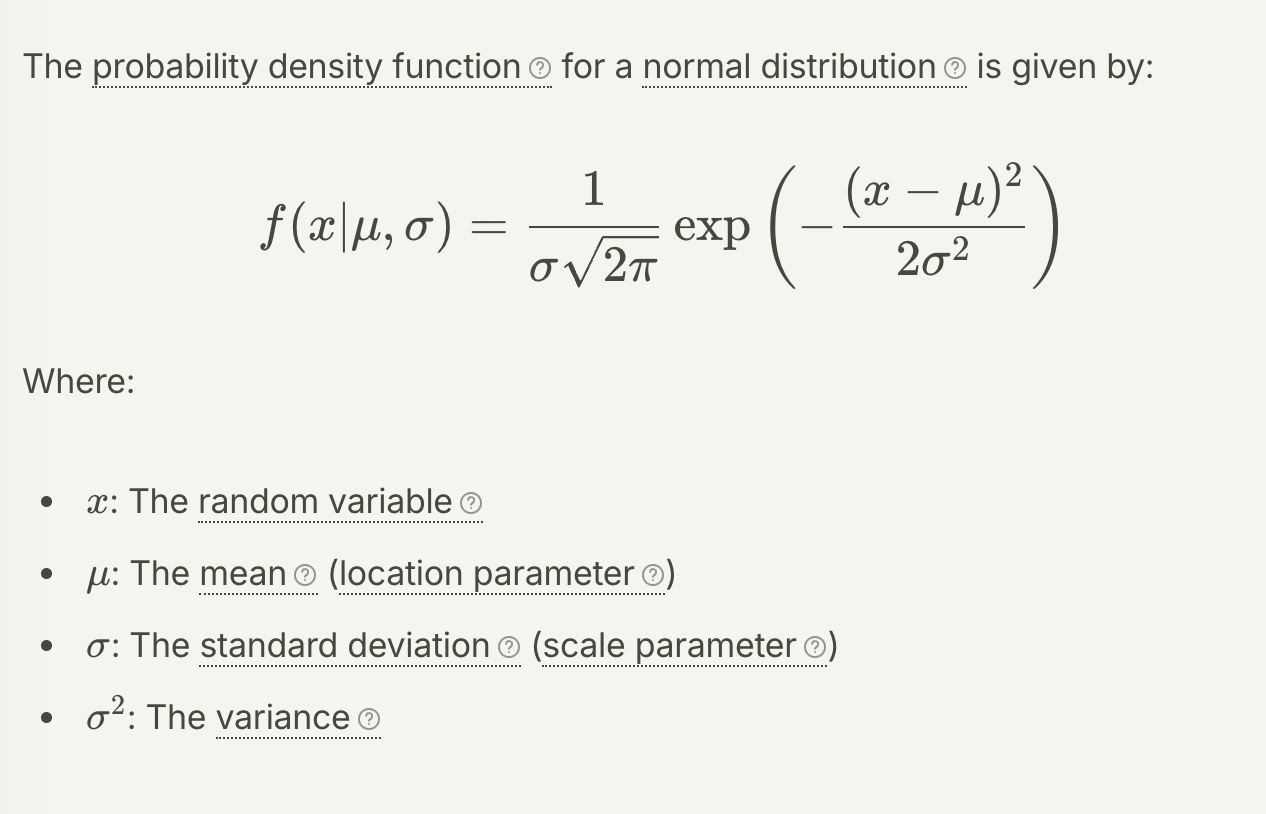

The normal distribution's importance stems partly from the Central Limit Theorem, which states that the sum (or average) of many independent random variables tends toward a normal distribution regardless of the underlying distribution of those variables. This remarkable result explains why measurement errors, aggregate quantities, and averaged data so often follow normal patterns, even when individual components do not.

In practice, the normal distribution appears in countless contexts. Human heights within demographic groups, measurement errors in scientific instruments, and financial returns over short time periods all approximately follow normal distributions. The distribution's mathematical tractability (particularly the fact that linear combinations of normal variables remain normally distributed) makes it the foundation for classical statistical methods such as linear regression and ANOVA.

**Example: Normal Distribution Visualization**:



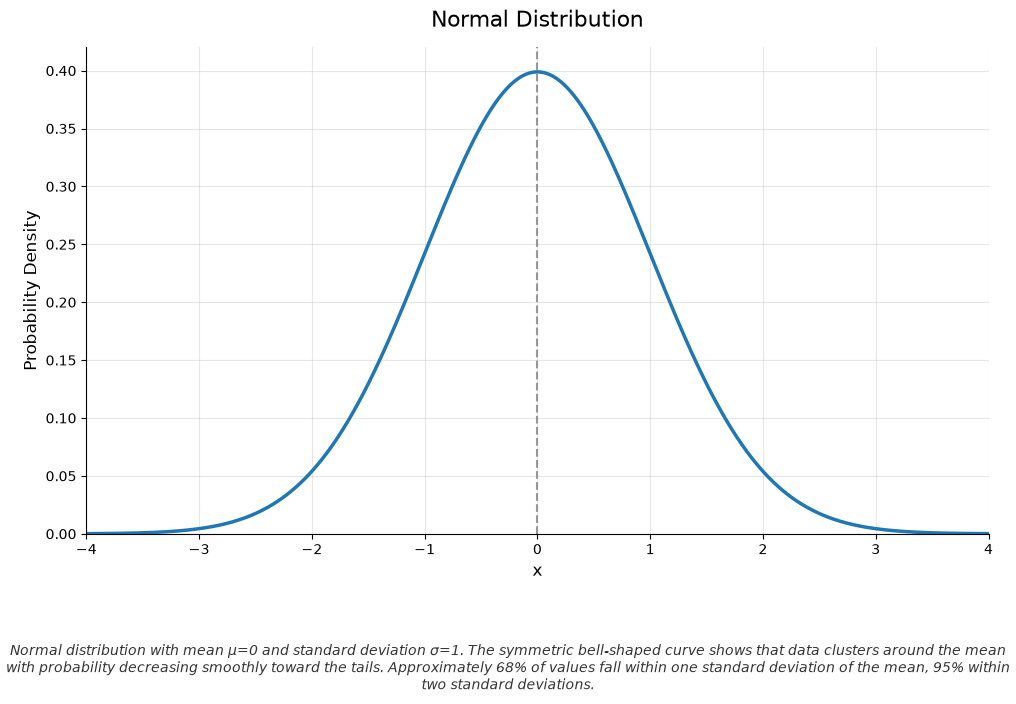

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters for standard normal distribution
mu = 0
sigma = 1

# x values
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, mu, sigma)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the PDF
ax.plot(x, y, color='#1f77b4', linewidth=2.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_title('Normal Distribution', fontsize=16, pad=15)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)

# Axis limits and ticks
ax.set_xlim(-4, 4)
ax.set_ylim(0, 0.42)
ax.set_xticks([-4, -3, -2, -1, 0, 1, 2, 3, 4])
ax.set_yticks([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40])

# Grid
ax.grid(True, linestyle='-', alpha=0.3)
ax.set_axisbelow(True)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# After the plot code above, before plt.show():
caption = (
    "Normal distribution with mean μ=0 and standard deviation σ=1. "
    "The symmetric bell-shaped curve shows that data clusters around the mean "
    "with probability decreasing smoothly toward the tails. "
    "Approximately 68% of values fall within one standard deviation of the mean, "
    "95% within two standard deviations."
)

fig.text(0.5, -0.08, caption, ha='center', va='top', fontsize=10, 
         wrap=True, style='italic', color='#333333')
plt.subplots_adjust(bottom=0.2)  # make room for caption

plt.savefig("Plots/NormalDistribution.png", dpi=150)
plt.tight_layout()
plt.show()

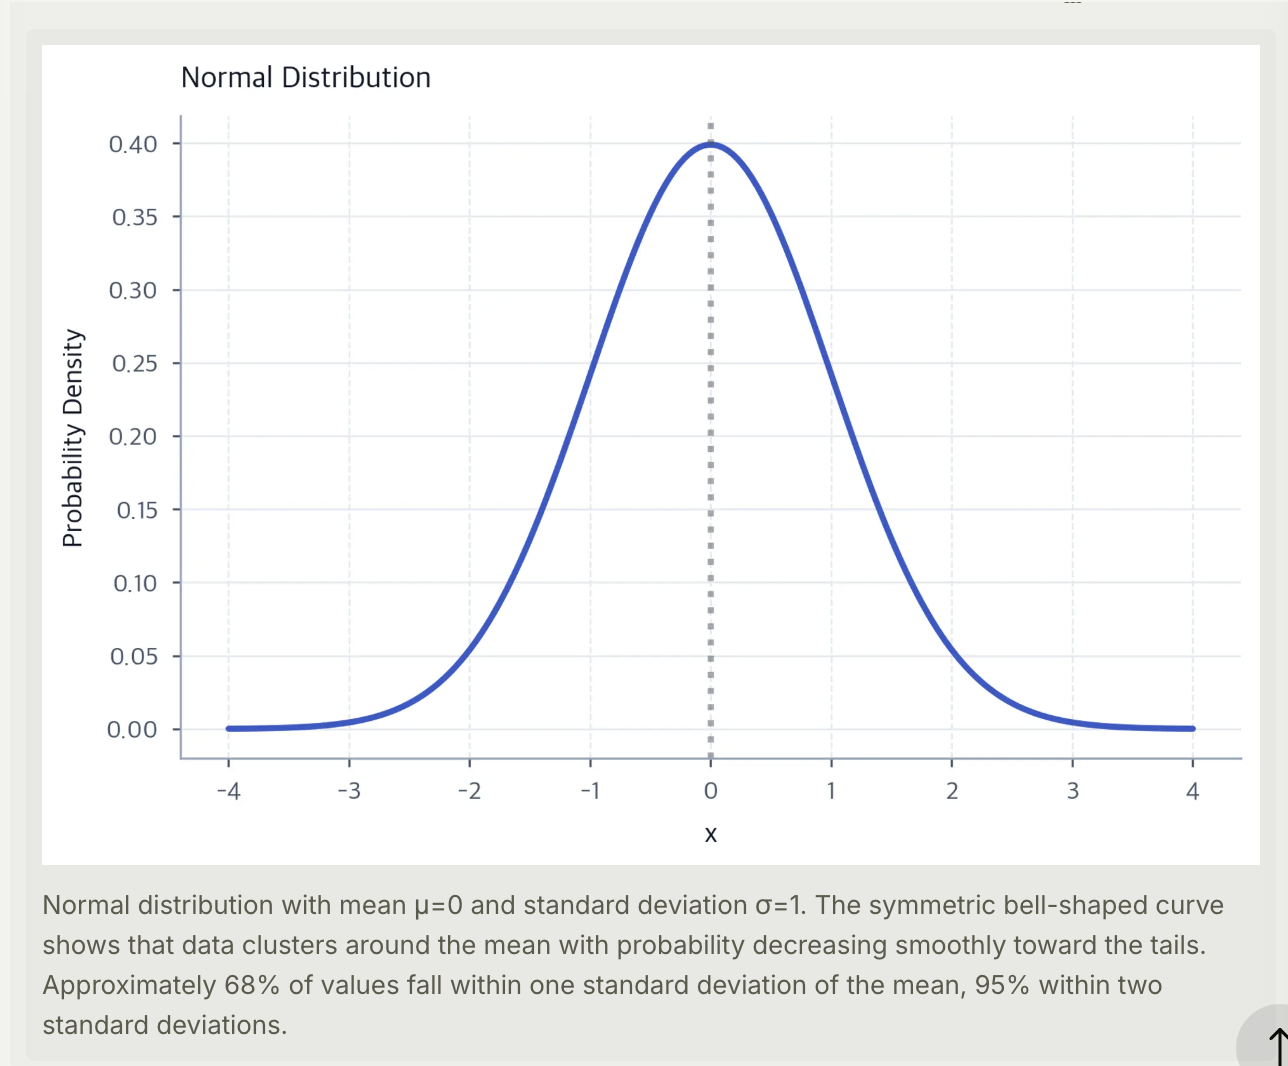

## 2. The t-Distribution

While the normal distribution assumes known population parameters, real-world inference typically works with sample estimates that carry their own uncertainty. The t-distribution addresses this reality by accounting for the additional variability introduced when estimating the population standard deviation from sample data.

The probability density function for the t-distribution is:

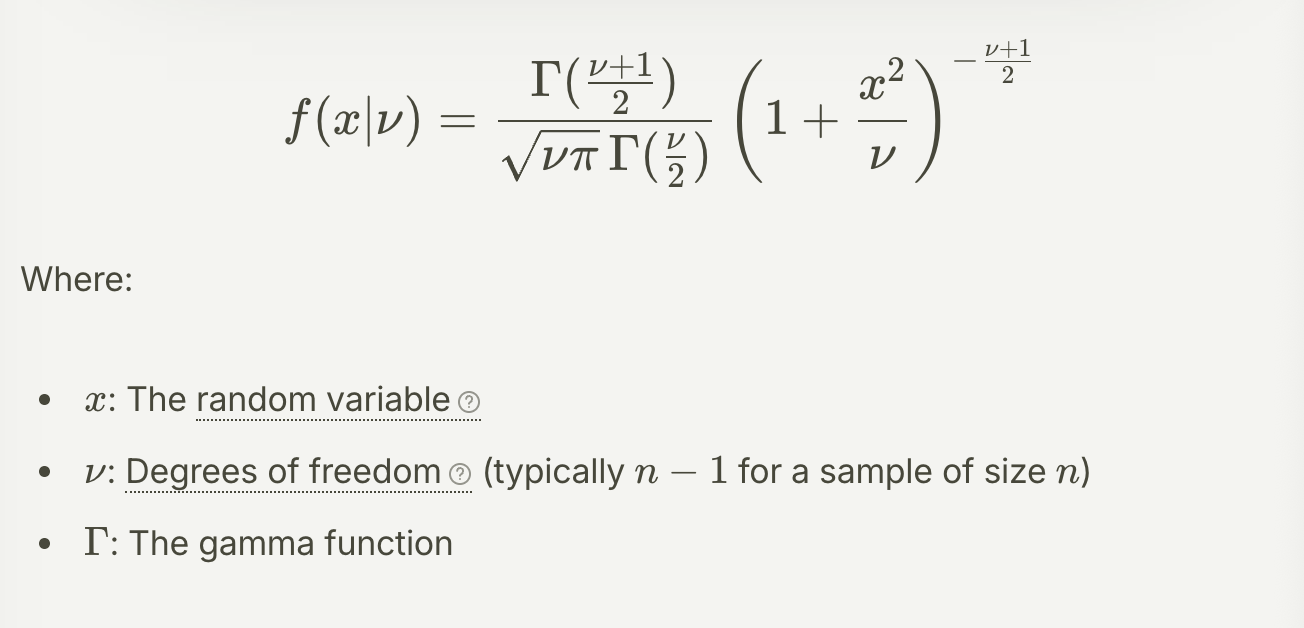

The t-distribution resembles a normal distribution but with heavier tails, meaning it assigns higher probability to extreme values. This characteristic reflects the greater uncertainty present when working with small samples. As the degrees of freedom increase (corresponding to larger sample sizes), the t-distribution converges to the standard normal distribution, capturing the intuition that larger samples provide more reliable estimates.

Data scientists encounter the t-distribution primarily in hypothesis testing and confidence interval construction when sample sizes are modest (typically fewer than 30 observations) and the population standard deviation is unknown. The t-test for comparing group means, one of the most widely used statistical procedures, derives its name and theoretical foundation from this distribution. When reporting whether an observed difference between groups is statistically significant, researchers rely on the t-distribution to quantify how unusual the observed result would be under the null hypothesis.

**Example:t-Distribution Visualization**:


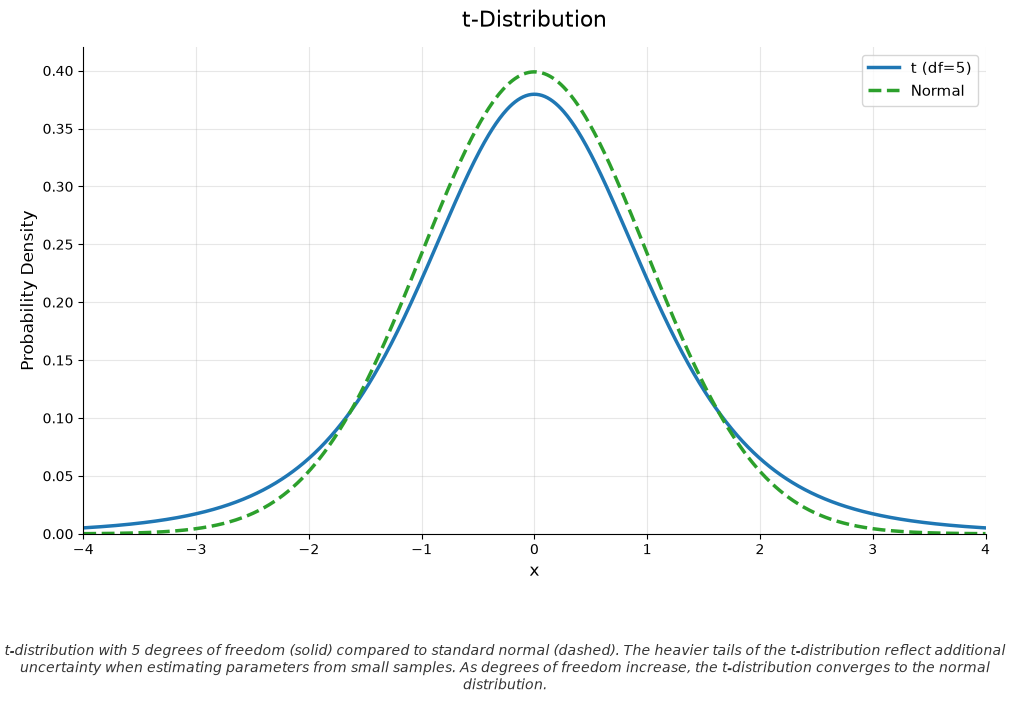

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# x values
x = np.linspace(-4, 4, 1000)

# t-distribution with 5 degrees of freedom
y_t = t.pdf(x, df=5)

# Standard normal distribution
y_norm = norm.pdf(x, loc=0, scale=1)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot both distributions
ax.plot(x, y_t, color='#1f77b4', linewidth=2.5, label='t (df=5)')
ax.plot(x, y_norm, color='#2ca02c', linewidth=2.5, linestyle='--', label='Normal')

# Labels and title
ax.set_title('t-Distribution', fontsize=16, pad=15)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)

# Axis limits and ticks
ax.set_xlim(-4, 4)
ax.set_ylim(0, 0.42)
ax.set_xticks([-4, -3, -2, -1, 0, 1, 2, 3, 4])
ax.set_yticks([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40])

# Grid
ax.grid(True, linestyle='-', alpha=0.3)
ax.set_axisbelow(True)

# Legend
ax.legend(loc='upper right', frameon=True, fontsize=11)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add this after the plot code and before plt.show():
caption = (
    "t-distribution with 5 degrees of freedom (solid) compared to standard normal (dashed). "
    "The heavier tails of the t-distribution reflect additional uncertainty when estimating "
    "parameters from small samples. As degrees of freedom increase, the t-distribution "
    "converges to the normal distribution."
)

fig.text(0.5, -0.08, caption, ha='center', va='top', fontsize=10,
         wrap=True, style='italic', color='#333333')
plt.subplots_adjust(bottom=0.22)


plt.savefig("Plots/tDistribution.png", dpi=150)
plt.tight_layout()
plt.show()

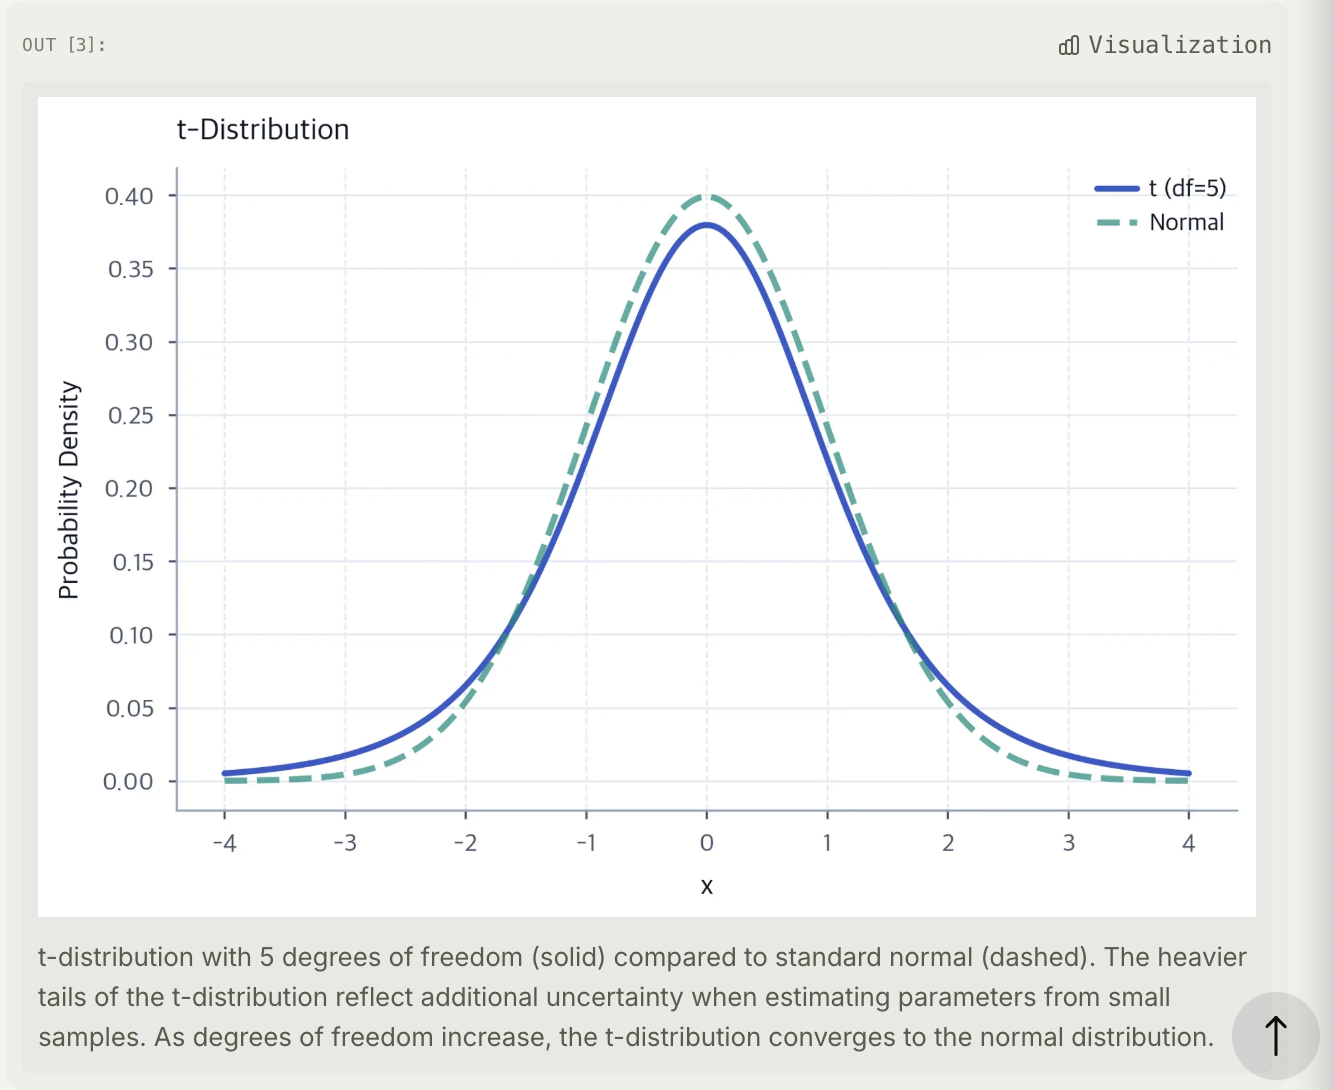

## 3. Binomial Distribution

Many practical problems involve counting successes in a fixed number of independent trials, each with the same probability of success. The binomial distribution provides the exact probability model for such scenarios, making it essential for analyzing binary outcomes and discrete event counts.

The probability mass function for the binomial distribution is:

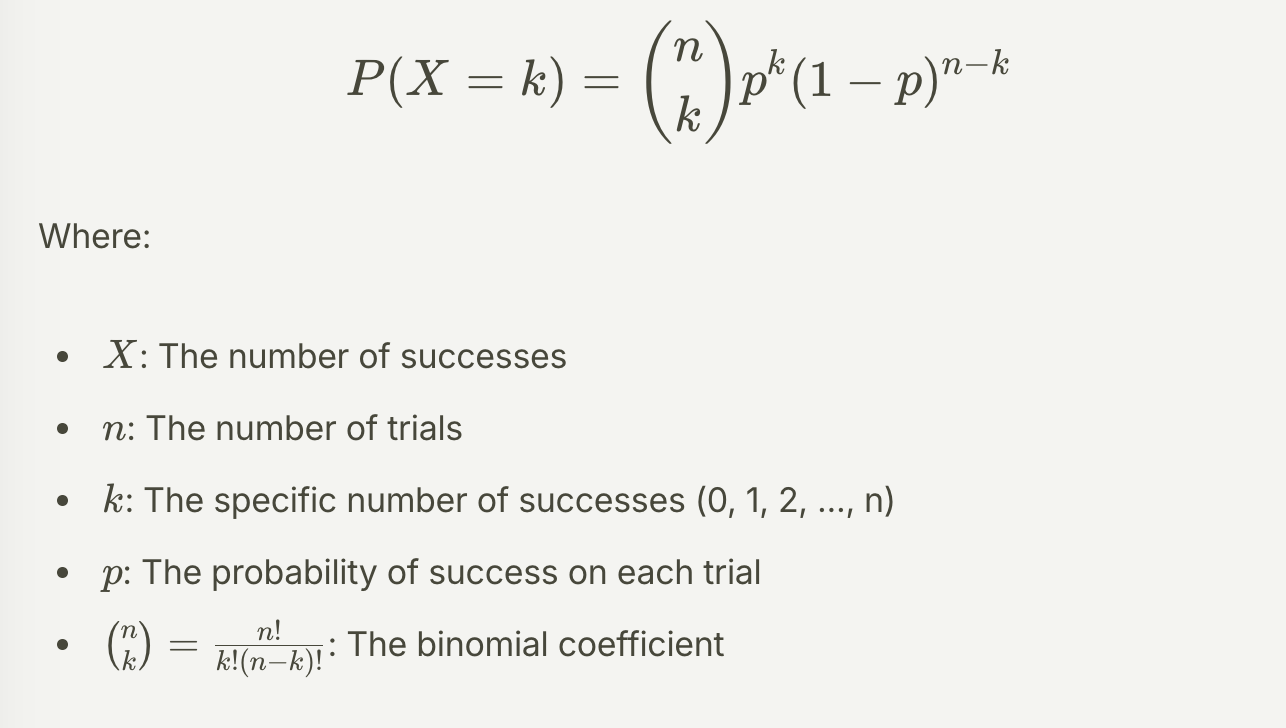

The binomial distribution applies whenever we can frame a problem as repeated independent Bernoulli trials: experiments with exactly two possible outcomes. Quality control scenarios offer clear examples: if a manufacturing process produces defective items with probability 
p, the number of defects in a batch of 
n items follows a binomial distribution.  Similarly, in A/B testing for web applications, the number of users who click a button out of
n visitors follows a binomial distribution if we assume independence between user actions.

Understanding the binomial distribution enables practitioners to calculate precise probabilities for discrete outcomes. For instance, if a website's conversion rate is 5%, we can determine the probability that exactly 3 out of 20 visitors make a purchase, or the probability that at least 2 visitors convert. These calculations inform decision-making about sample sizes, detection of anomalies, and assessment of whether observed conversion rates differ significantly from historical baselines.

**Example: Binomial Distribution Visualization**

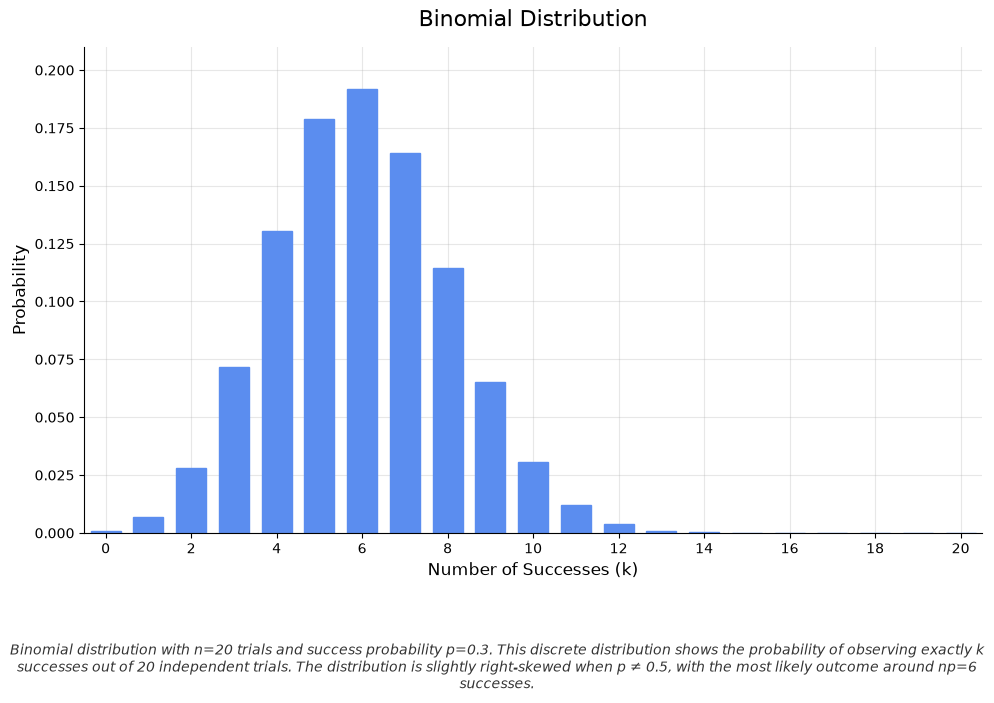

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters
n = 20          # number of trials
p = 0.3         # success probability
k = np.arange(0, n + 1)

# Probability mass function
pmf = binom.pmf(k, n, p)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot
bars = ax.bar(k, pmf, color='#5B8DEF', edgecolor='#5B8DEF', width=0.7)

# Labels and title
ax.set_title('Binomial Distribution', fontsize=16, pad=15)
ax.set_xlabel('Number of Successes (k)', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)

# Axis limits and ticks
ax.set_xlim(-0.5, 20.5)
ax.set_ylim(0, 0.21)
ax.set_xticks(np.arange(0, 21, 2))
ax.set_yticks([0.000, 0.025, 0.050, 0.075, 0.100, 0.125, 0.150, 0.175, 0.200])

# Grid
ax.grid(True, linestyle='-', alpha=0.3, axis='both')
ax.set_axisbelow(True)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

caption = (
    "Binomial distribution with n=20 trials and success probability p=0.3. "
    "This discrete distribution shows the probability of observing exactly k successes "
    "out of 20 independent trials. The distribution is slightly right-skewed when p ≠ 0.5, "
    "with the most likely outcome around np=6 successes."
)

fig.text(0.5, -0.08, caption, ha='center', va='top', fontsize=10,
         wrap=True, style='italic', color='#333333')
plt.subplots_adjust(bottom=0.22)
plt.savefig("Plots/BinomialDistribution.png", dpi=150)
plt.tight_layout()
plt.show()

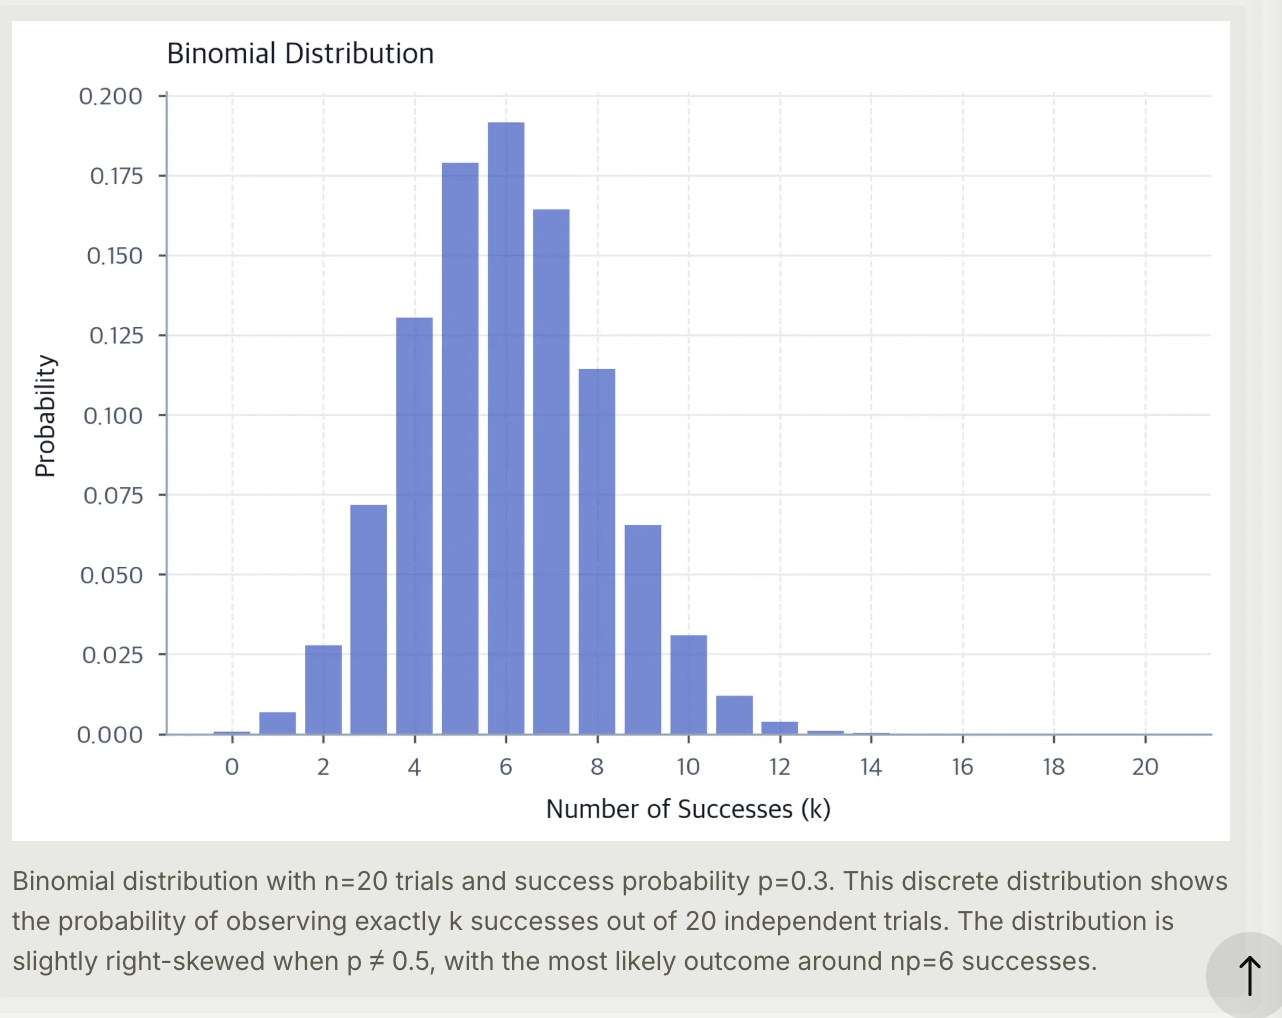

## 4. The Poisson Distribution

While the binomial distribution counts successes in a fixed number of trials, many real-world processes involve counting events that occur randomly over time or space without a predetermined number of opportunities. The Poisson distribution models such scenarios, describing the probability of observing a specific number of events in a fixed interval.

The probability mass function for the Poisson distribution is

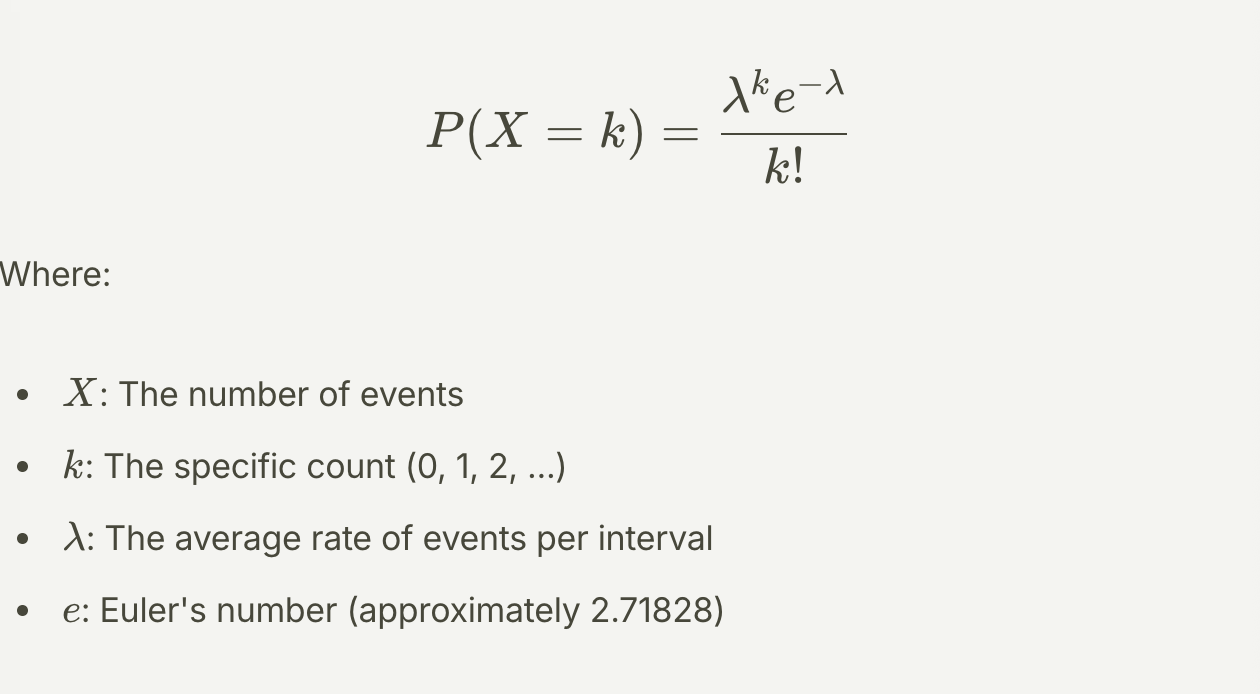

The Poisson distribution arises naturally when events occur independently at a constant average rate. Customer arrivals at a service counter, defects in manufactured materials, and server requests hitting a web application per minute often follow Poisson patterns. The distribution's single parameter 
λ represents both the mean and variance, which is a distinctive and useful property. If we know the average rate, we fully characterize the distribution.

In data science applications, the Poisson distribution frequently appears in modeling rare events and count data. Network traffic analysis uses Poisson models to predict congestion and allocate resources. In healthcare, the number of disease cases in a population over time often follows Poisson patterns, enabling epidemiologists to detect outbreaks when observed counts significantly exceed expected rates. The distribution also forms the basis for Poisson regression, a technique for modeling count outcomes as functions of predictor variables.

**Example: Poisson Distribution Visualization**



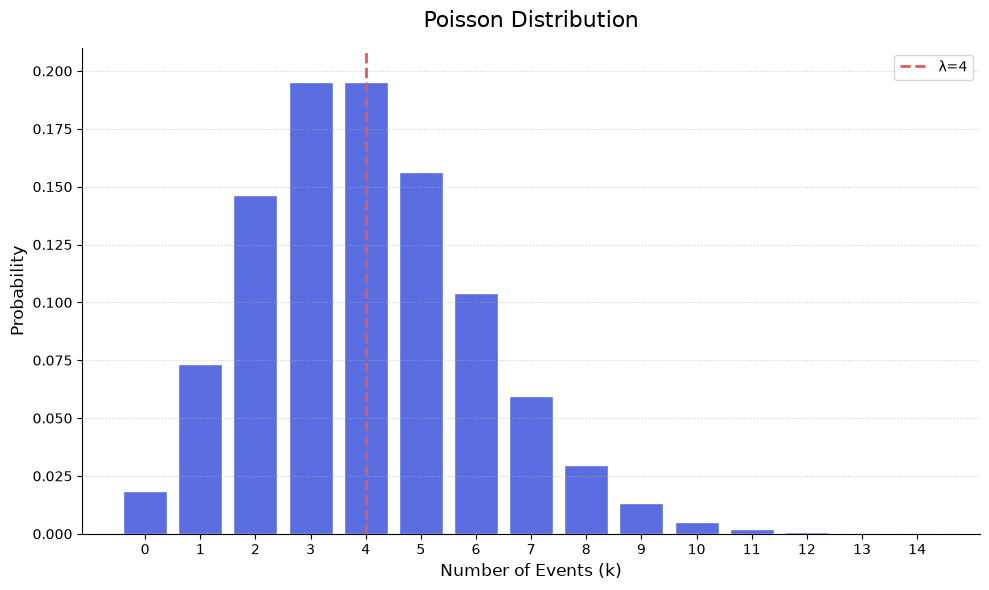

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parameters
lambda_ = 4
k_values = np.arange(0, 15)          # 0 to 14
probabilities = poisson.pmf(k_values, lambda_)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot
bars = ax.bar(k_values, probabilities, color='#5B6EE1', edgecolor='white', width=0.8)

# Vertical dashed line at the mean (λ = 4)
ax.axvline(x=lambda_, color='#E05A5A', linestyle='--', linewidth=2, label=f'λ={lambda_}')

# Styling
ax.set_title('Poisson Distribution', fontsize=16, pad=15)
ax.set_xlabel('Number of Events (k)', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_xticks(k_values)
ax.set_ylim(0, 0.21)
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
ax.legend(loc='upper right', frameon=True)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("Plots/PoissonDistribution.png", dpi=150)
plt.tight_layout()
plt.show()

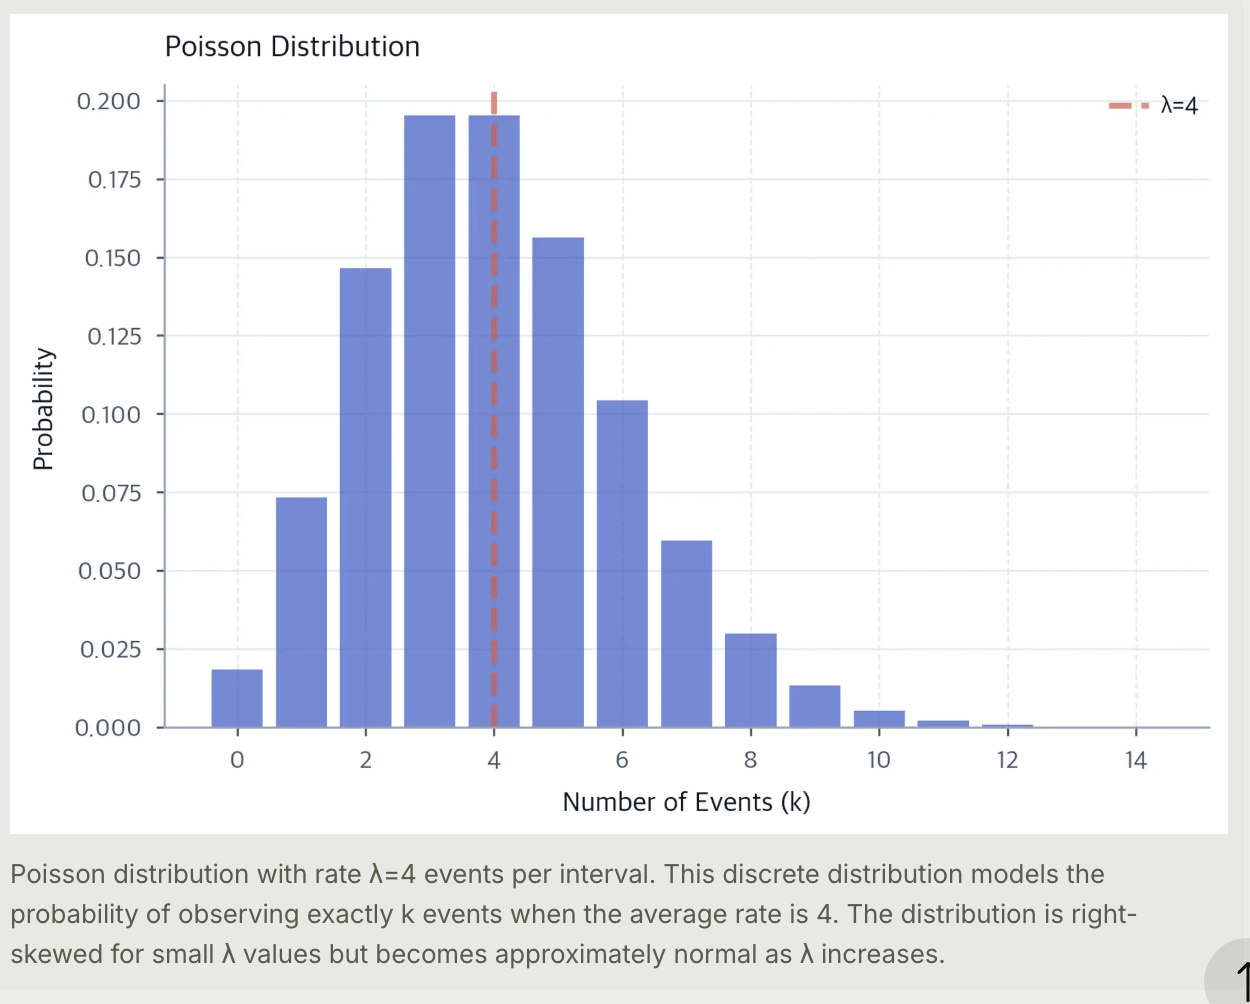

## 5. The Exponential Distribution

The exponential distribution describes the time between events in a Poisson process. If events occur according to a Poisson distribution with rate 
λ, the waiting time until the next event follows an exponential distribution. This relationship makes the exponential distribution fundamental for modeling time-to-event data and system reliability.

The probability density function for the exponential distribution is:

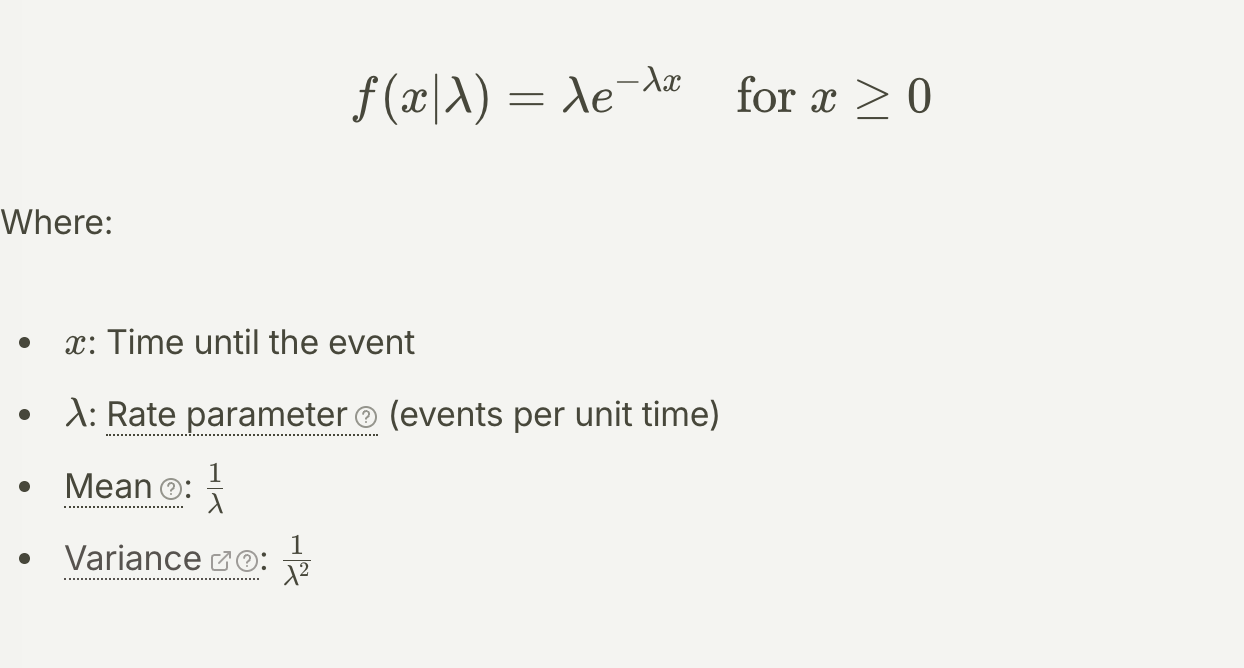

The exponential distribution possesses a unique memoryless property: the probability that an event occurs in the next time interval is independent of how much time has already elapsed. Mathematically, 
$P(X>s+t∣X>s)=P(X>t) for all s,t≥0$.While this property may seem counterintuitive (we might expect that if a component has survived a long time, it's either more or less likely to fail soon), it accurately describes many random processes where each moment carries the same instantaneous failure rate.

In practice, the exponential distribution models scenarios where failure or events can happen at any moment with constant probability. Customer service call durations, time until equipment failure for components without wear-out mechanisms, and intervals between incoming emails or messages often approximate exponential distributions. Reliability engineers use the exponential distribution to calculate mean time between failures (MTBF) and design maintenance schedules, while queuing theorists employ it to model service times and optimize system capacity.


**Example:Exponential Distribution**

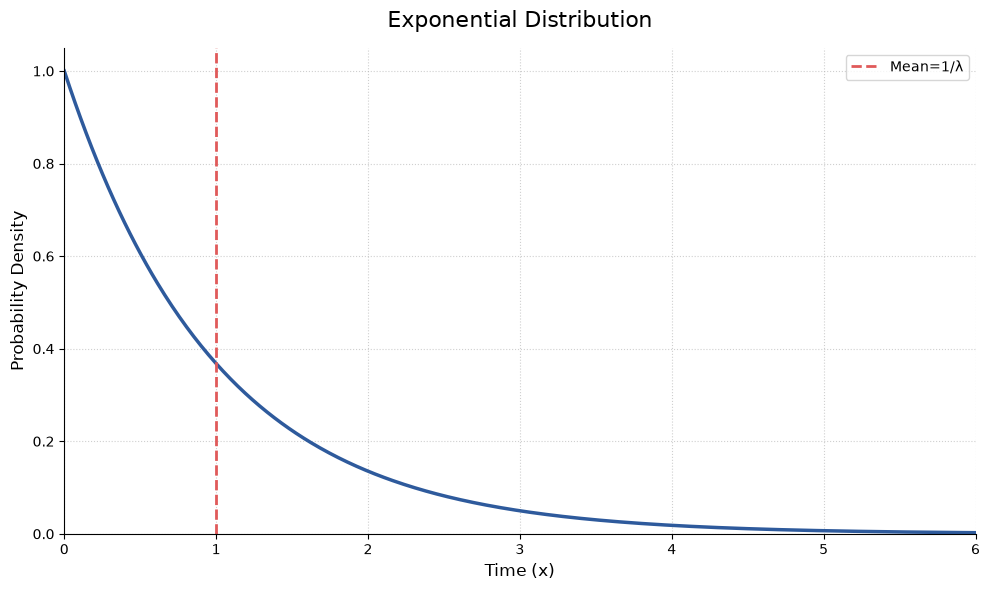

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Parameters
lambda_ = 1.0                  # rate parameter
mean = 1 / lambda_             # mean = 1/λ
x = np.linspace(0, 6, 500)     # time values
pdf = expon.pdf(x, scale=1/lambda_)   # PDF of Exponential(λ)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the PDF curve
ax.plot(x, pdf, color='#2E5A9C', linewidth=2.5)

# Vertical dashed line at the mean
ax.axvline(x=mean, color='#E05A5A', linestyle='--', linewidth=2, label='Mean=1/λ')

# Styling
ax.set_title('Exponential Distribution', fontsize=16, pad=15)
ax.set_xlabel('Time (x)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_xlim(0, 6)
ax.set_ylim(0, 1.05)
ax.set_xticks(np.arange(0, 7, 1))
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', frameon=True)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("Plots/ExponentialDistribution.png", dpi=150)
plt.tight_layout()
plt.show()

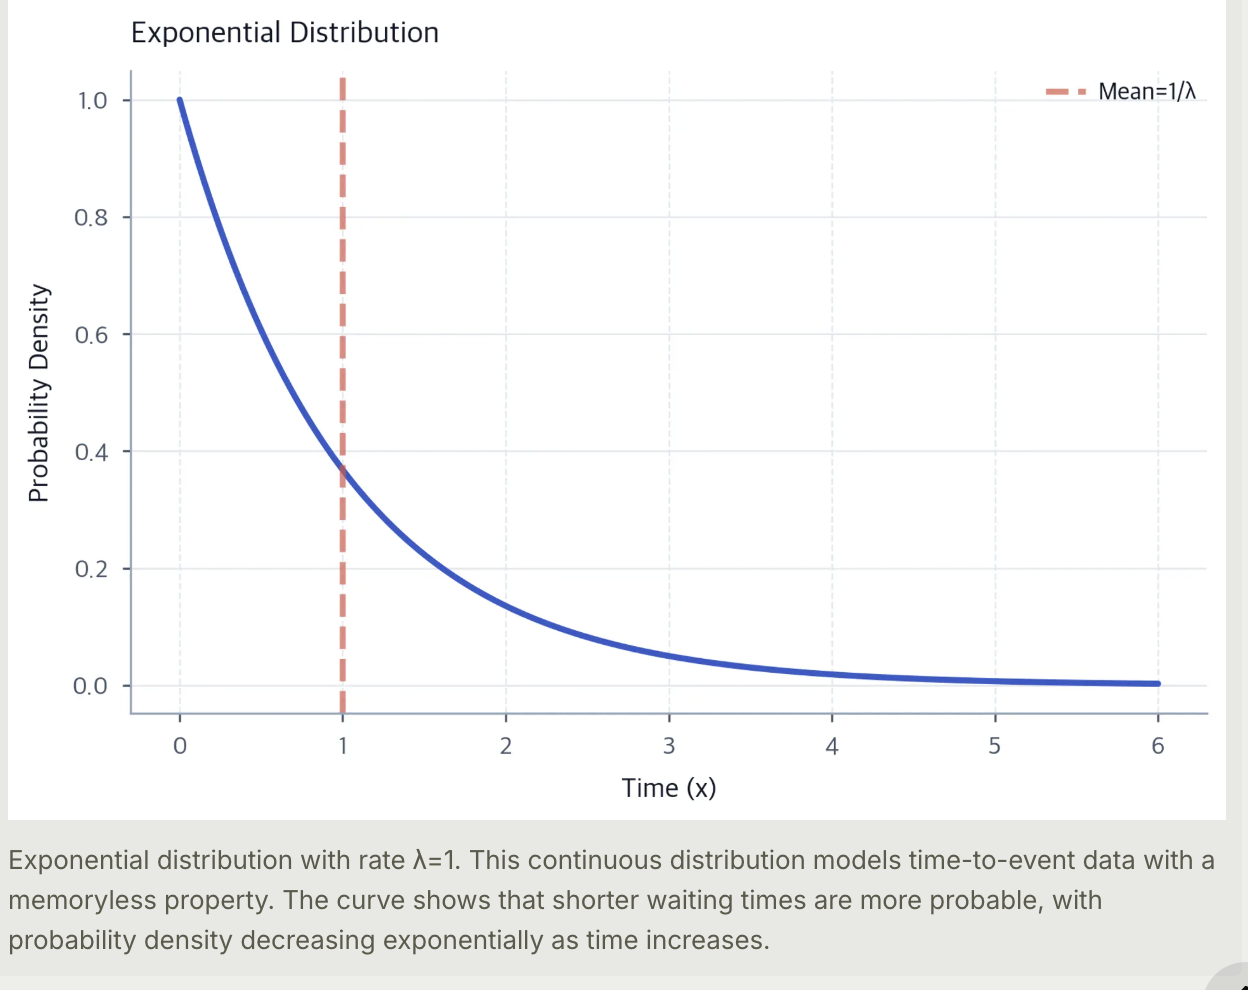

## 6. The Log-Norm Distribution

Many real-world quantities cannot take negative values and exhibit right-skewed distributions where most observations cluster at lower values while a long tail extends toward higher values. The log-normal distribution naturally captures this asymmetric pattern, arising when the logarithm of a variable is normally distributed.

The probability density function for the log-normal distribution is:

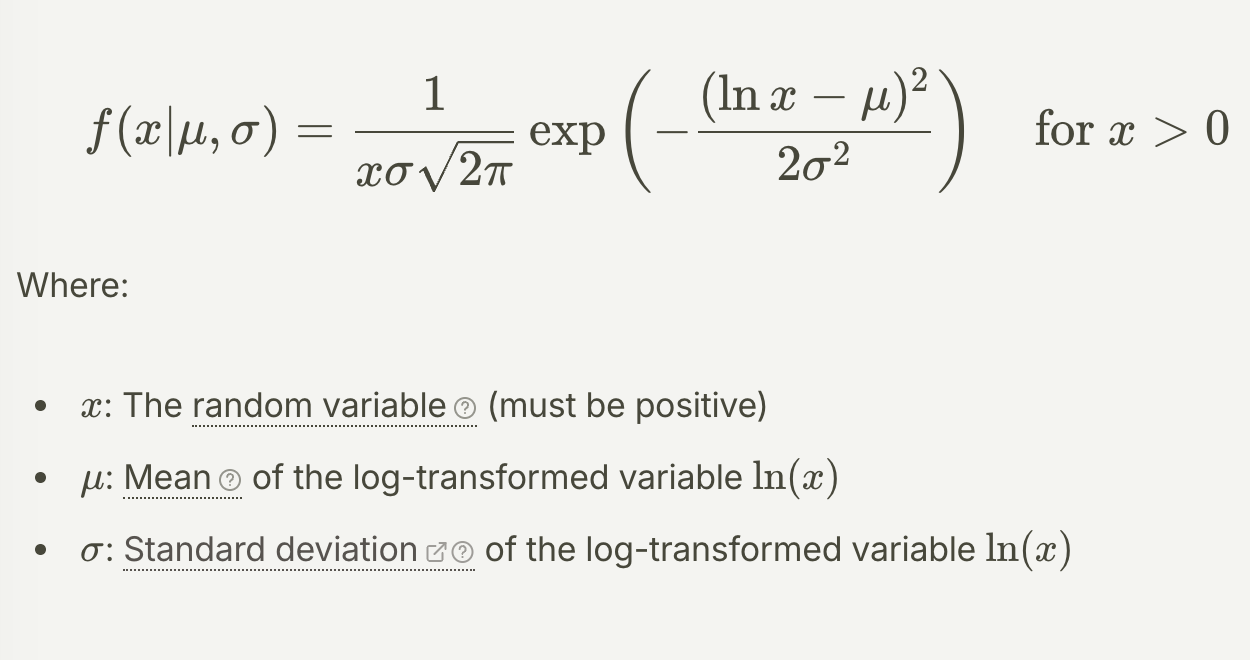

The log-normal distribution emerges naturally from multiplicative processes. When a quantity results from many independent multiplicative factors (rather than additive factors as in the Central Limit Theorem), it tends toward a log-normal distribution. This mechanism explains why the distribution appears so frequently in economic and biological contexts where growth processes compound proportionally.

Incomes and wealth distributions, stock prices, file sizes in computer systems, and particle sizes in materials science commonly follow log-normal patterns. In finance, asset returns may be approximately normal over short periods, but asset prices themselves follow log-normal distributions since prices cannot be negative and percentage changes compound multiplicatively. Biomedical researchers encounter log-normal distributions when analyzing drug concentrations in the body, latency periods for diseases, and metabolic rates across species.

When working with log-normal data, analysts typically transform variables by taking logarithms before applying standard statistical methods designed for normal distributions. After analysis, results can be back-transformed to the original scale, though care must be taken since the mean of a log-normal variable does not equal the exponential of the mean of the log-transformed variable.


**Exponential: Log-Normal Distribution Visualization**:


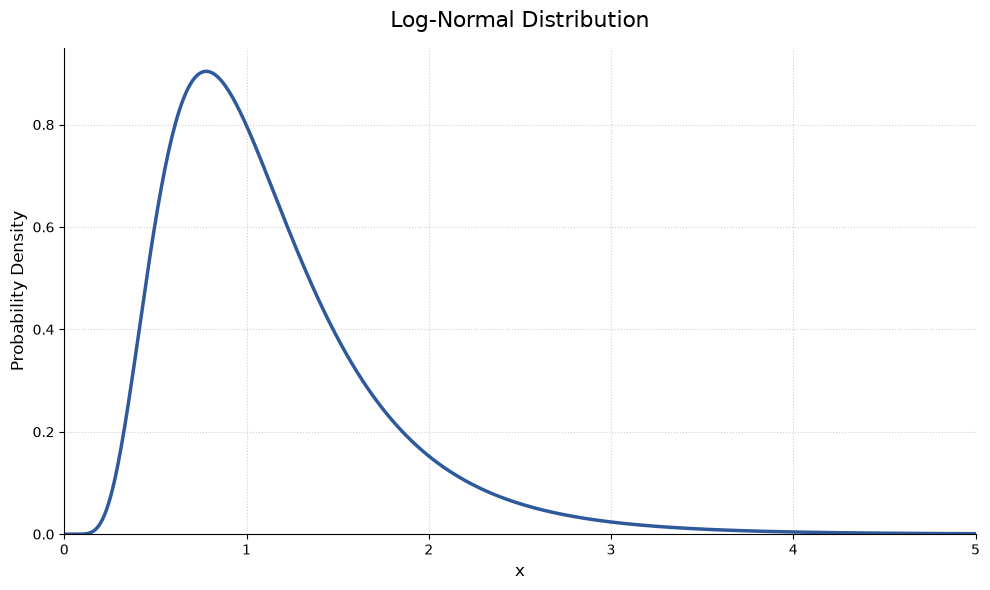

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Parameters
mu = 0.0          # mean of the underlying normal distribution
sigma = 0.5       # standard deviation of the underlying normal
x = np.linspace(0.001, 5, 500)   # avoid x=0 because log(0) is undefined

# PDF of Log-Normal(μ, σ)
# scipy uses shape=σ and scale=exp(μ)
pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu))

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the PDF curve
ax.plot(x, pdf, color='#2E5A9C', linewidth=2.5)

# Styling
ax.set_title('Log-Normal Distribution', fontsize=16, pad=15)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_xlim(0, 5)
ax.set_ylim(0, 0.95)
ax.set_xticks(np.arange(0, 6, 1))
ax.grid(True, linestyle=':', alpha=0.6)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("Plots/LogNormDistribution.png", dpi=150)
plt.tight_layout()
plt.show()

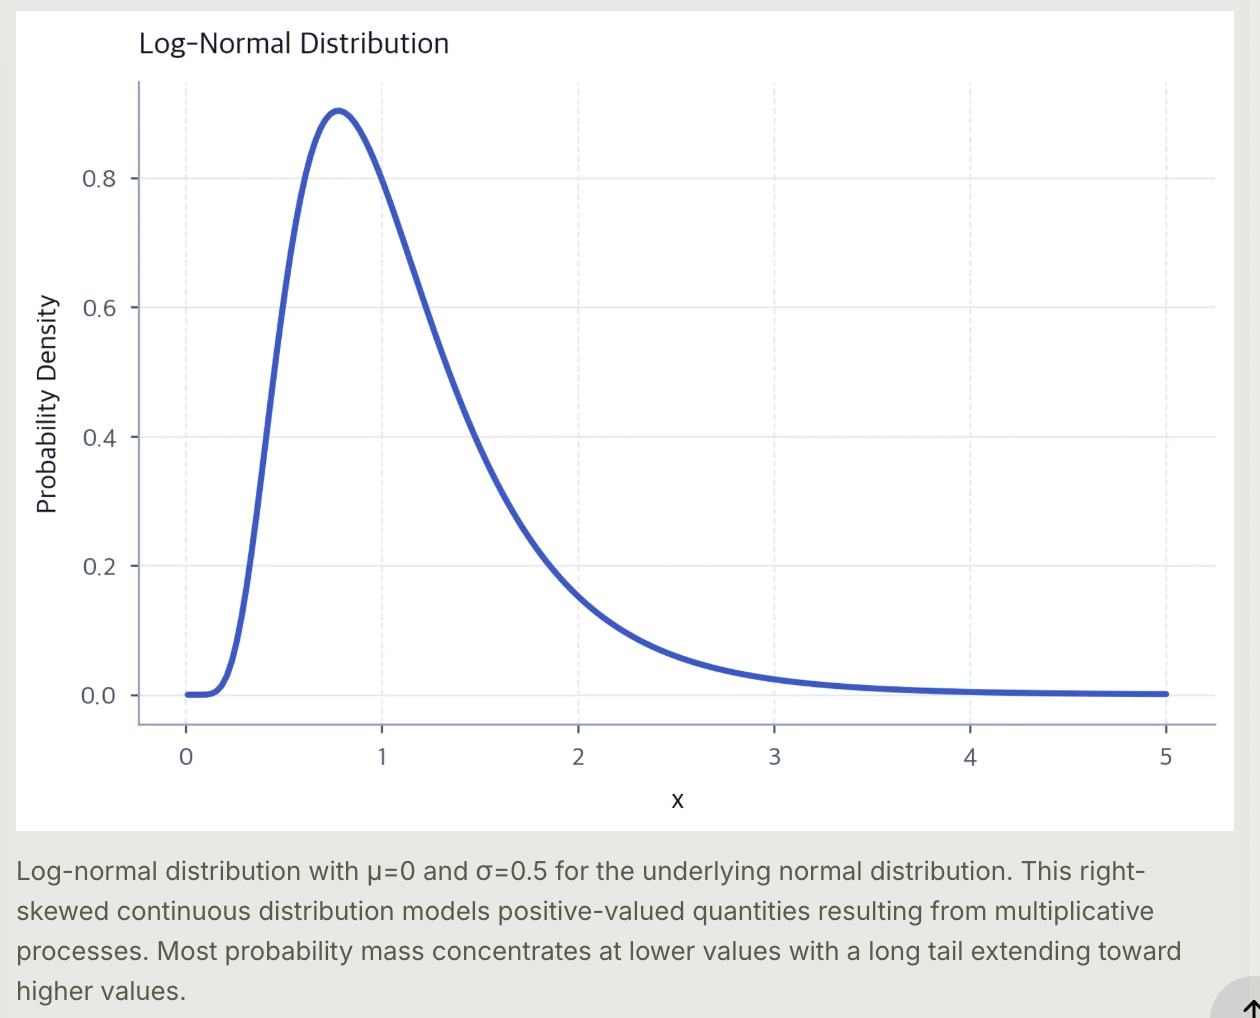

## 7. Choosing the Right Distribution

Selecting an appropriate probability distribution for data analysis or modeling requires careful consideration of the data's characteristics and the underlying process that generated it. Several key questions guide this decision process, helping practitioners match theoretical distributions to empirical observations.

First, determine whether the data is discrete or continuous. Discrete data with countable outcomes (such as the number of customer complaints per day or defects per batch) suggests discrete distributions like binomial or Poisson. Continuous measurements (such as temperatures, durations, or concentrations) point toward continuous distributions like normal, exponential, or log-normal.

Next, consider the range of possible values. If data can only be positive, distributions defined on 
$x>0$ like exponential or log-normal become natural candidates, immediately ruling out the normal distribution which allows negative values.  For count data bounded by a fixed number of trials, the binomial distribution applies, while unbounded counts suggest Poisson models.

The shape of the data distribution provides additional clues. Symmetric data clustering around a central value often follows normal patterns, while right-skewed data with a long tail toward higher values may indicate log-normal or exponential distributions. Examining histograms and quantile-quantile (Q-Q) plots helps assess which theoretical distribution aligns best with observed patterns.

Finally, consider the underlying mechanism generating the data. If the process involves independent trials with fixed success probability, the binomial distribution provides theoretical justification. If events occur randomly over time at a constant rate, Poisson and exponential distributions derive from first principles. Understanding the data-generating process points to appropriate distributions and helps validate the modeling assumptions behind them.

## 8. Limitations and Considerations
While probability distributions provide powerful frameworks for understanding data, practitioners must recognize their limitations and avoid common pitfalls. Real-world data rarely follows theoretical distributions exactly, and misapplication of distributional assumptions can lead to invalid inferences and poor predictions.

The binomial and Poisson distributions assume independence, as does the exponential distribution. This assumption frequently breaks down in practice. Events may cluster in time, trial outcomes may depend on previous results, and observations may exhibit correlation structures. When independence fails, standard formulas for probabilities and confidence intervals become inaccurate, potentially leading to overconfident conclusions.

Stationarity represents another critical assumption often violated in real data. The Poisson distribution assumes events occur at a constant rate, but many processes exhibit time-varying rates: customer arrivals peak during business hours, system failures increase as equipment ages, and disease incidence fluctuates seasonally. Applying stationary models to non-stationary processes can produce misleading results unless the data is first segmented into homogeneous periods.

Sample size considerations affect distributional approximations differently across contexts. While the Central Limit Theorem guarantees that sample means approach normality for large samples regardless of the underlying distribution, convergence rates depend on how far the true distribution deviates from normality. Highly skewed or heavy-tailed distributions require larger samples before normal approximations become reliable. Similarly, the Poisson approximation to the binomial distribution works well when 
n is large and 
p is small, but fails otherwise.

Practitioners should always validate distributional assumptions through exploratory data analysis rather than assuming them by default. Goodness-of-fit tests, Q-Q plots, and residual diagnostics help assess whether chosen distributions adequately describe observed data. When standard distributions prove inadequate, mixture models, empirical distributions, or more flexible distribution families may provide better representations of reality.


## 9. Practical Applications

Understanding probability distributions allows data scientists to tackle diverse analytical challenges across industries and domains. Each distribution serves specific use cases where its mathematical properties align with real-world data characteristics.

In quality control and manufacturing, the binomial distribution supports acceptance sampling plans. Engineers determine how many items to inspect from production batches and establish decision rules for accepting or rejecting lots based on observed defect counts. By calculating probabilities under the binomial model, organizations balance the costs of inspection against the risks of accepting defective batches or rejecting good ones.

Financial institutions apply the log-normal distribution extensively in options pricing and risk management. The Black-Scholes option pricing model assumes that stock prices follow log-normal distributions, enabling analysts to calculate fair values for derivatives. Risk managers use log-normal models to estimate Value-at-Risk (VaR) and simulate portfolio outcomes under various market scenarios, accounting for the positive-only constraint on asset prices.

Web analytics and digital marketing rely heavily on exponential distributions for session duration analysis and conversion modeling. Product managers examine how long users remain engaged with applications, fitting exponential models to estimate average session lengths and identify factors that increase retention. A/B testing frameworks use binomial distributions to power sample size calculations and determine when observed conversion rate differences reach statistical significance.


## Summary

Probability distributions provide the mathematical foundation for statistical inference and data science practice. The normal distribution remains central due to its mathematical properties and connection to the Central Limit Theorem, describing symmetric continuous data that clusters around a mean. When working with small samples and unknown population parameters, the t-distribution accounts for additional uncertainty through its heavier tails.

For discrete event modeling, the binomial and Poisson distributions offer complementary perspectives. The binomial distribution models a fixed number of independent trials with binary outcomes, while the Poisson distribution describes counts of events occurring randomly over time or space. The exponential distribution naturally connects to the Poisson process by modeling waiting times between events and capturing the memoryless property of constant hazard rates.

When data exhibits right skewness with positive values only, the log-normal distribution provides an appropriate model, arising naturally from multiplicative growth processes. This distribution appears frequently in economic and biological contexts where quantities compound proportionally rather than additively.

Selecting the right distribution requires examining data characteristics (discrete versus continuous, range of possible values, symmetry versus skewness) alongside understanding the underlying data-generating mechanism. While theoretical distributions rarely match real data perfectly, they provide valuable approximations that enable rigorous statistical inference and effective predictive modeling. Success in applying distributions depends on validating assumptions, recognizing limitations, and interpreting results within appropriate contexts.